# Use Stability AI text-to-image model to create an image

In [ ]:
#pip install diffusers

In [ ]:
#pip install invisible_watermark accelerate safetensors

## SDXL (high quality, classic diffusion)

check [here](https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0) for more detail of the model

In [ ]:
from diffusers import StableDiffusionXLPipeline
import torch
import matplotlib.pyplot as plt

In [ ]:
%%time

pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16
).to("cuda")

prompt = "a cozy bookshelf nook, warm sunlight, film grain"
image = pipe(prompt, num_inference_steps=35, guidance_scale=7.0).images[0]

image.save("images/bookshelf_sdxl.png")

# Display image
plt.imshow(image)
plt.axis('off')
plt.title("Loaded Image")
plt.show()

In [ ]:
def sa_text_to_image(prompt, image_name):
    pipe = StableDiffusionXLPipeline.from_pretrained(
        "stabilityai/stable-diffusion-xl-base-1.0",
        torch_dtype=torch.float16
    ).to("cuda")

    prompt = prompt
    image = pipe(prompt, num_inference_steps=35, guidance_scale=7.0).images[0]

    image.save("images/"+image_name+".png")

    # Display image
    plt.imshow(image)
    plt.axis('off')
    plt.title("Loaded Image")
    plt.show()

In [ ]:
prompt="a happy golden retriever in the sun"
image_name="golder_retriever"

sa_text_to_image(prompt, image_name)

## Stable Diffusion 3 Medium

Stable Diffusion 3 Medium is a Multimodal Diffusion Transformer (MMDiT) text-to-image model that features greatly improved performance in image quality, typography, complex prompt understanding, and resource-efficiency.

## Note: To use stable-diffusion-3-medium model, you need to login your huggingface account and pass a token

Please sign in your account first, and then click your profile--> Setting--> Access Tokens

You can store your token in your environment file.

## If you got an error message cuda out of memory, please stop/restart the server. 

In [ ]:
pip install sentencepiece

In [1]:
# log in your huggingface account

import os
from huggingface_hub import login

login(token=os.getenv("HF_TOKEN"))

In [2]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

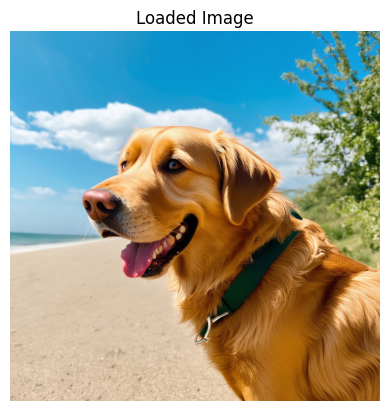

CPU times: user 32.5 s, sys: 20.6 s, total: 53.1 s
Wall time: 27.1 s


In [3]:
%%time

import torch
from diffusers import StableDiffusion3Pipeline
import matplotlib.pyplot as plt


pipe = StableDiffusion3Pipeline.from_pretrained("stabilityai/stable-diffusion-3-medium-diffusers", torch_dtype=torch.float16)
pipe = pipe.to("cuda")

#prompt="A cat holding a sign that says hello world"
prompt="a happy golden retriever in the sun"

image = pipe(
    prompt,
    negative_prompt="",
    num_inference_steps=28,
    guidance_scale=7.0,
).images[0]

image.save("images/cat_sd3.png")

# Display image
plt.imshow(image)
plt.axis('off')
plt.title("Loaded Image")
plt.show()